In [24]:
import torch
from torch import nn
import matplotlib.pyplot as plt

torch.__version__


'2.5.1'

In [2]:
#Create known parameters 
weight=0.7
bias=0.3

#Creating a data 
start=0
end=1
step=0.02
X=torch.arange(start, end, step).unsqueeze(dim=1)#creating a tensor with step of 0.02 and output gives the shape like [50] so we unsqueeze to add
                                                 #the dimensions then output will be [50,1]. we are doing this because the layers expect the input like
                                                 #batch_size and features
y=weight * X + bias #linear regrssion formula or slop formula
X[:10], y[:10], len(X) , len(y) 

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]),
 50,
 50)

In [3]:
X.shape, y.shape

(torch.Size([50, 1]), torch.Size([50, 1]))

In [25]:
#splitting data into training and test datasets

train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split] , y[:train_split]
X_test,y_test = X[train_split:] , y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [26]:
#X_train, y_train

In [27]:
#creating a function graph to visualize
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
    plt.figure(figsize=(8,5))
    #plot training date in blue
    plt.scatter(train_data, train_labels, c="b",s=4,label="Training data")
    #plot test data in green
    plt.scatter(test_data, test_labels, c="y",s=4,label="Testing data")

    if predictions is not None:
        #plot the prediciton if they exist
        plt.scatter(test_data, predictions,c="r",s=4,label="Predictions")
    plt.legend()                 

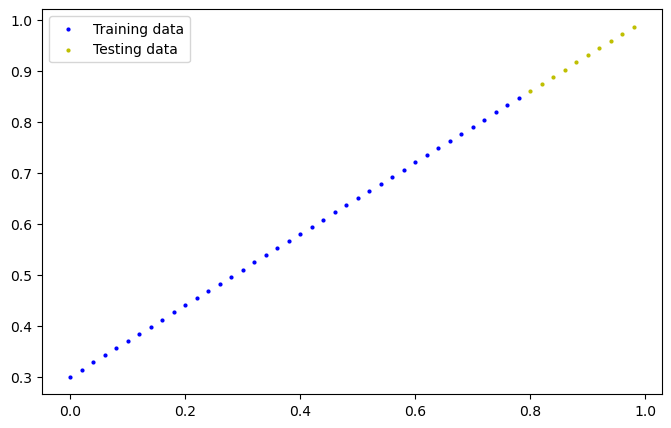

In [7]:
plot_predictions()

In [28]:
#Building a Model
#Creating a linear regression model

class LinearRegressionModel(nn.Module):#nn.module is a base class(parent class) for all neural network and it tells like this class is a neural network module
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, requires_grad = True,
                                                   dtype=torch.float))
        self.bias=nn.Parameter(torch.randn(1, requires_grad = True,
                                                   dtype=torch.float))

    def forward(self, x: torch.Tensor) -> torch.Tensor:#forward fucntion tells How input data flows through the model.and the parameter is x with type hint
        return self.weights * x + self.bias # Linear Regression formula

In [29]:
#Checking the contents of our model

torch.manual_seed(42)

model_0 =LinearRegressionModel()

list(model_0.parameters())#check out the parameters


[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [30]:
#list the named parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [31]:
#Making prediction using torch.inference_mode(), it basically disables the gradient calculations. NOT track gradients.

with torch.inference_mode():
    y_preds=model_0(X_test)

y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

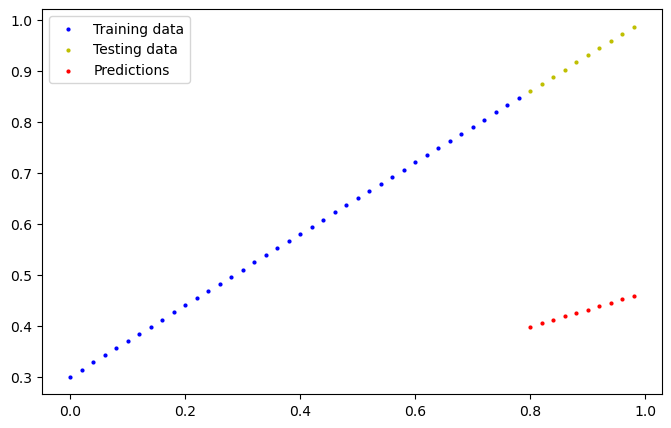

In [32]:
plot_predictions(predictions=y_preds)

In [33]:
#Training Model

#setup a loss function
loss_fn=nn.L1Loss()

#setup an optimizer( stochasticc gradient descent)
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.01)



In [36]:
#Building a training a loop and testinga loop
torch.manual_seed(42)
# Set the number of epochs (how many times the model will pass over the training data)
epochs=100

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []


for epoch in range(epochs):
    #putting the model in training mode
    model_0.train()
    
    # forward pass on train data using forward() method inside 
    y_pred = model_0(X_train)
    
    #Calculate the loss
    loss = loss_fn(y_pred, y_train)#measure error
    print(f"Loss : {loss}")
    #reseting the gradient to zero before calculation new gradients(reset gradients)
    optimizer.zero_grad()

    #here where magic happens ,it compute gradients (doing differentiation) how much each parameter contributed to the error
    loss.backward()

    #updates parameters using gradient descent (update weights)
    optimizer.step()

    #put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
        test_pred = model_0(X_test)

        test_loss = loss_fn(test_pred, y_test.type(torch.float))

        if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")


Loss : 0.024458957836031914
Epoch: 0 | MAE Train Loss: 0.024458957836031914 | MAE Test Loss: 0.05646304413676262 
Loss : 0.024110013619065285
Loss : 0.02376994863152504
Loss : 0.02342480979859829
Loss : 0.023080935701727867
Loss : 0.022739607840776443
Loss : 0.022391926497220993
Loss : 0.022054409608244896
Loss : 0.02170540764927864
Loss : 0.021366719156503677
Loss : 0.021020207554101944
Epoch: 10 | MAE Train Loss: 0.021020207554101944 | MAE Test Loss: 0.04819049686193466 
Loss : 0.020677709951996803
Loss : 0.02033500373363495
Loss : 0.01998869702219963
Loss : 0.019649803638458252
Loss : 0.019300809130072594
Loss : 0.018963487818837166
Loss : 0.01861560344696045
Loss : 0.018274478614330292
Loss : 0.017930403351783752
Loss : 0.01758546568453312
Epoch: 20 | MAE Train Loss: 0.01758546568453312 | MAE Test Loss: 0.04060482233762741 
Loss : 0.017245199531316757
Loss : 0.016896454617381096
Loss : 0.01656000316143036
Loss : 0.016210997477173805
Loss : 0.01587124727666378
Loss : 0.0155257983133

In [37]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

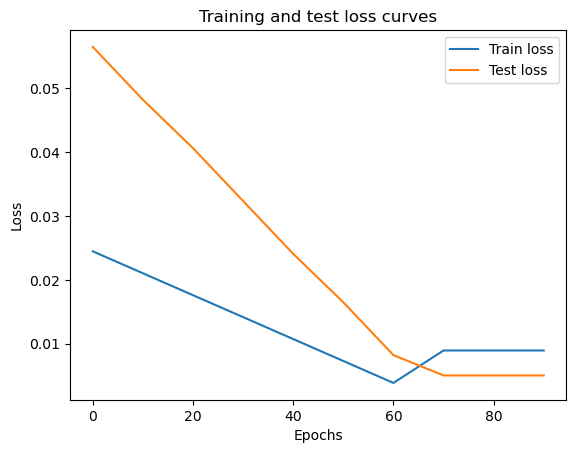

In [38]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

In [39]:
#finding out our model learned parameters
print("The learned weight and bias")
print(model_0.state_dict())
print(f" weight: {weight}, bias: {bias}")

The learned weight and bias
OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])
 weight: 0.7, bias: 0.3


In [40]:
#Making predictions with trained pytorch model
#1 set the model in evaluation mode
model_0.eval()

#2 setup the inference mode 
with torch.inference_mode():
    y_preds = model_0(X_test)

y_preds

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

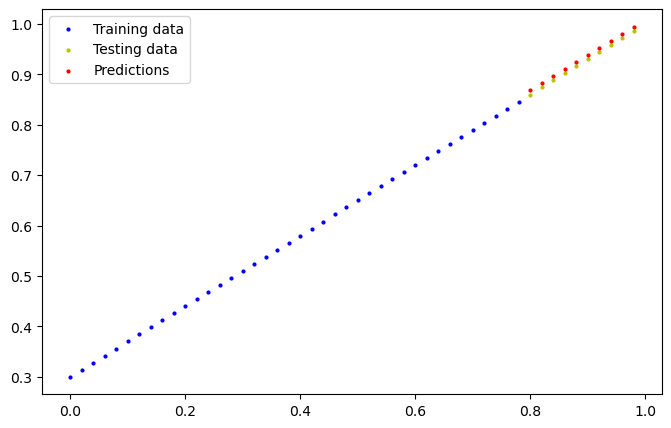

In [41]:
plot_predictions(predictions = y_preds)

In [44]:
#saving the model locally
torch.save(model_0.state_dict(),"my_first_model.pth")


In [47]:
# loading a saved pytorch model

#create a instance of model class
model_1 = LinearRegressionModel()

#load the state_dict of our saved model
model_1.load_state_dict(torch.load("my_first_model.pth", weights_only=True))

<All keys matched successfully>

In [48]:
#testing our loaded model
model_1.eval()

with torch.inference_mode():
    model_1_pred = model_1(X_test)

In [51]:
y_preds == model_1_pred

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])